# 预处理

In [1]:
# 英语和西班牙语的数据中经常会出现一些带有重音或变音符号的字符（比如西班牙语中的á、ñ，法语中的é等），这些字符会影响后续的文本标准化、分词和词汇表构建。
# 为了简化处理流程，我们常常会将所有字符转换为ASCII编码，也就是去除掉重音或者特殊符号，使不同写法统一到同一个标准字符。
# 这样可以减少词汇表的复杂性，有助于模型更快收敛、降低过拟合风险，尤其是在只关注语义、不关心拼写细节的机器翻译场景。
import unicodedata
import re
def unicode_to_ascii(s):
    # NFD将字符串的每个字符拆分为基础字符和所有的重音符号/修饰 (Normalize Form D)
    # Mn表示所有的Nonspacing_Mark（即重音符等），这里将这些去除，实现ascii化
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# 举个例子，西班牙语和英文都有不同特殊字符
# 将字符串转为ASCII可以消除如 ¿, á, é, ñ 等带重音/特殊字符的差异，统一到基础字母
en_sentence = u"May I borrow, this book?"
sp_sentence = u"¿Puedo tomar prestado este libro?"

print(unicode_to_ascii(en_sentence))    # May I borrow, this book?
print(unicode_to_ascii(sp_sentence))    # ¿Puedo tomar prestado este libro?

May I borrow, this book?
¿Puedo tomar prestado este libro?


In [2]:
def preprocess_sentence(w):
    """
    w是某一个样本的句子
    """
    #变为小写，去掉多余的空格，变成小写，id少一些
    w = unicode_to_ascii(w.lower().strip())

    # 在单词与跟在其后的 标点符号?.!,¿ 之间插入一个空格
    # eg: "he is a boy." => "he is a boy . "
    # Reference:- https://stackoverflow.com/questions/3645931/python-padding-punctuation-with-white-spaces-keeping-punctuation
    w = re.sub(r"([?.!,¿])", r" \1 ", w)


    # 除了 (a-z, A-Z, ".", "?", "!", ",")，将所有字符替换为空格，你可以保留一些标点符号
    w = re.sub(r"[^a-zA-Z?.!,¿]+", " ", w)

    #因为可能有多余空格，替换为一个空格，所以处理一下
    w = re.sub(r'[" "]+', " ", w)

    w = w.strip() #strip是去掉两边的空格

    return w

# 用 preprocess_sentence 处理上面定义的两个句子
print(preprocess_sentence(en_sentence))    # May i borrow , this book ?
print(preprocess_sentence(sp_sentence))    # ? puedo tomar prestado este libro ?

may i borrow , this book ?
¿ puedo tomar prestado este libro ?


# 制作Dataset

In [3]:
import numpy as np

# 读取 spa.txt 文件
path_to_file = 'spa.txt'
# 读取所有行
with open(path_to_file, encoding='utf-8') as f:
    lines = f.read().strip().split('\n')

# 每一行分为英文和西班牙语
word_pairs = []
for l in lines:
    en, sp = l.split('\t')
    word_pairs.append((en, sp))

# 打乱数据
np.random.seed(42)
np.random.shuffle(word_pairs)

# 9:1 划分训练集和测试集
n_total = len(word_pairs)
n_train = int(n_total * 0.9)
train_pairs = word_pairs[:n_train]
test_pairs = word_pairs[n_train:]

# 制作Dataset（这里只是生成分好train/test的样本对清单，后续可以根据模型需要做进一步处理）
print(f"总样本数: {n_total}, 训练集: {len(train_pairs)}，测试集: {len(test_pairs)}")
print("训练集样本举例：")
for i in range(3):
    print(train_pairs[i])
print("测试集样本举例：")
for i in range(3):
    print(test_pairs[i])

总样本数: 118964, 训练集: 107067，测试集: 11897
训练集样本举例：
('How boring!', '¡Qué aburrimiento!')
('I love sports.', 'Adoro el deporte.')
('Would you like to swap jobs?', '¿Te gustaría que intercambiemos los trabajos?')
测试集样本举例：
('Even Tom has his doubts.', 'Incluso Tomás tiene sus dudas.')
('Who can speak French better, Tom or Mary?', '¿Quién sabe hablar francés mejor: Tom o Mary?')
('Tom came just before dinner.', 'Tom vino justo antes de la cena.')


In [4]:
class TranslationDataset:
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        en, sp = self.pairs[idx]
        # 返回（西班牙语，英语），均经过 preprocess_sentence 处理
        return preprocess_sentence(sp), preprocess_sentence(en)

# 示例：创建训练集、测试集的Dataset对象，并取样结果
train_dataset = TranslationDataset(train_pairs)
test_dataset  = TranslationDataset(test_pairs)

print("Dataset 取样结果举例：")
for i in range(3):
    sp, en = train_dataset[i]
    print(f"西班牙语: {sp}\n英语: {en}\n")

Dataset 取样结果举例：
西班牙语: que aburrimiento !
英语: how boring !

西班牙语: adoro el deporte .
英语: i love sports .

西班牙语: ¿ te gustaria que intercambiemos los trabajos ?
英语: would you like to swap jobs ?



# Tokenizer构建

In [5]:
# 基于训练集构建英语和西班牙语的词典（tokenizer/vocab）
from collections import Counter

def build_vocab(sentences, min_freq=1):
    counter = Counter()
    for s in sentences:
        counter.update(s.split())
    # 保留频率大于等于min_freq的词
    # 常规特殊符号: PAD, UNK, BOS, EOS
    vocab = ['<PAD>', '<UNK>', '<BOS>', '<EOS>'] + [w for w, c in counter.items() if c >= min_freq]
    word2idx = {w: i for i, w in enumerate(vocab)}
    id2word = {i: w for i, w in enumerate(vocab)}
    return word2idx, id2word

# 分别采集训练集中的西班牙语、英语句子
sp_sentences = []
en_sentences = []
for i in range(len(train_dataset)):
    sp, en = train_dataset[i]
    sp_sentences.append(sp)
    en_sentences.append(en)

# 构建西班牙语和英语词典
sp_word2idx, sp_id2word = build_vocab(sp_sentences)
en_word2idx, en_id2word = build_vocab(en_sentences)

print(f"西班牙语词典大小: {len(sp_word2idx)}")
print(f"英语词典大小: {len(en_word2idx)}")

# 查看部分样例
print(f"西班牙语词表前10: {[sp_id2word[i] for i in range(10)]}")
print(f"英语词表前10: {[en_id2word[i] for i in range(10)]}")

西班牙语词典大小: 23754
英语词典大小: 12478
西班牙语词表前10: ['<PAD>', '<UNK>', '<BOS>', '<EOS>', 'que', 'aburrimiento', '!', 'adoro', 'el', 'deporte']
英语词表前10: ['<PAD>', '<UNK>', '<BOS>', '<EOS>', 'how', 'boring', '!', 'i', 'love', 'sports']


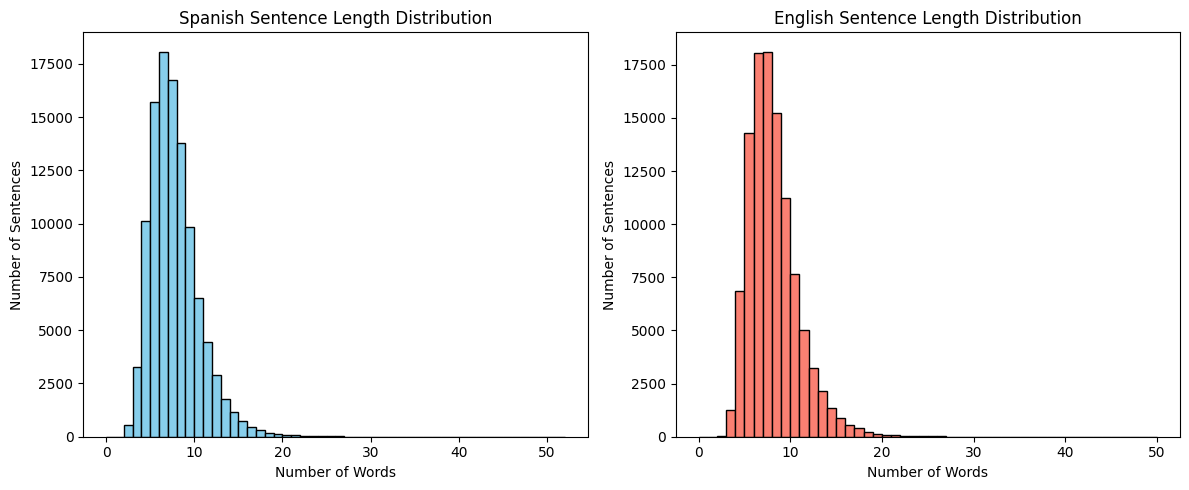

51
49


In [6]:
import matplotlib.pyplot as plt

# Calculate the tokenized sentence lengths for Spanish and English
sp_lens = [len(s.split()) for s in sp_sentences]
en_lens = [len(s.split()) for s in en_sentences]

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.hist(sp_lens, bins=range(0, max(sp_lens)+2, 1), color='skyblue', edgecolor='black')
plt.title('Spanish Sentence Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Number of Sentences')

plt.subplot(1, 2, 2)
plt.hist(en_lens, bins=range(0, max(en_lens)+2, 1), color='salmon', edgecolor='black')
plt.title('English Sentence Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Number of Sentences')

plt.tight_layout()
plt.show()
print(max(sp_lens))
print(max(en_lens))

In [7]:
class Tokenizer:
    def __init__(self, word2idx, id2word):
        self.word2idx = word2idx
        self.id2word = id2word
        self.pad_token = '<PAD>'
        self.unk_token = '<UNK>'
        self.bos_token = '<BOS>'
        self.eos_token = '<EOS>'
        self.pad_idx = word2idx[self.pad_token]
        self.unk_idx = word2idx[self.unk_token]
        self.bos_idx = word2idx[self.bos_token]
        self.eos_idx = word2idx[self.eos_token]

    def encode(self, sentences, max_length=None, add_bos=True, add_eos=True, pad_side='right'):
        """
        输入: sentences 是一个批次（batch）的字符串列表。
        输出: 每个字符串对应的token id列表，带BOS/EOS并pad为定长。
        支持BOS/EOS/PAD加在左/右两侧的方式
        - pad_side: 'right'（右侧padding）或 'left'（左侧padding）
        - add_bos: 是否加BOS
        - add_eos: 是否加EOS
        返回: List[List[int]]
        """
        batch_ids = []  # 用于存放batch中所有句子的编码结果
        ids_list = []   # 保存未pad的id序列
        for sentence in sentences:  # 遍历batch中的每个句子
            tokens = sentence.split()  # 将句子按空格分词
            ids = []  # 当前句子的token id序列
            if add_bos:  # 是否加BOS符号
                ids.append(self.bos_idx)  # 加入BOS的索引
            ids.extend([self.word2idx.get(w, self.unk_idx) for w in tokens])  # 逐词查id，加UNK回退
            if add_eos:  # 是否加EOS符号
                ids.append(self.eos_idx)  # 加入EOS的索引
            ids_list.append(ids)  # 暂存未pad的结果

        # 计算本batch的最大长度
        pad_length = max(len(ids) for ids in ids_list)
        if max_length is not None:
            pad_length = min(pad_length, max_length)

        for ids in ids_list:
            if len(ids) < pad_length:
                pad_count = pad_length - len(ids)
                if pad_side == 'right':
                    ids = ids + [self.pad_idx] * pad_count
                elif pad_side == 'left':
                    ids = [self.pad_idx] * pad_count + ids
                else:
                    raise ValueError("pad_side 应为 'left' 或 'right'")
            else:
                # 若超长则截断，保证BOS和EOS等在正确位置
                if pad_side == 'right':
                    ids = ids[:pad_length]  # 右侧截断
                    if add_eos and ids[-1] != self.eos_idx:
                        ids[-1] = self.eos_idx
                else:  # pad_side == 'left'
                    ids = ids[-pad_length:]  # 左侧截断
                    if add_eos and ids[-1] != self.eos_idx:
                        ids[-1] = self.eos_idx
            batch_ids.append(ids)
        return batch_ids

    def decode(self, batch_ids, remove_special_tokens=True):
        """
        输入: batch_ids 是一个batch的token id列表（List[List[int]]）
        输出: 去除特殊符号的句子列表
        """
        results = []  # 存放还原后的句子
        for ids in batch_ids:  # 遍历每个句子的id序列
            tokens = []  # 当前句子的token串
            for idx in ids:  # 遍历该句子的每个token id
                token = self.id2word.get(idx, self.unk_token)  # 根据id查token
                if remove_special_tokens and token in {self.pad_token, self.bos_token, self.eos_token}:  # 跳过特殊token
                    continue
                tokens.append(token)  # 加入正常token
            results.append(' '.join(tokens))  # 合成还原后的句子
        return results  # 返回batch中全部解码句子
 

# 示例
sp_tokenizer = Tokenizer(sp_word2idx, sp_id2word)
en_tokenizer = Tokenizer(en_word2idx, en_id2word)

# 简单测试
sample_en = en_sentences[150:155]
encoded_en = en_tokenizer.encode(sample_en, max_length=10)
decoded_en = en_tokenizer.decode(encoded_en)
print(f"English sentence: {sample_en}")
# 输出每个句子的原文、编码、解码结果上下对齐
for i in range(len(sample_en)):
    print(f"Original: {sample_en[i]}")
    print(f"Encoded : {encoded_en[i]}")
    print(f"Decoded : {decoded_en[i]}")
    print('-' * 40)

English sentence: ['do you like renaissance art ?', 'stop that car .', 'from this point , we ll go on foot .', 'tom had a very good time .', 'i told you i don t know if tom will tell the truth .']
Original: do you like renaissance art ?
Encoded : [2, 169, 12, 13, 405, 406, 17, 3, 0, 0]
Decoded : do you like renaissance art ?
----------------------------------------
Original: stop that car .
Encoded : [2, 292, 96, 262, 10, 3, 0, 0, 0, 0]
Decoded : stop that car .
----------------------------------------
Original: from this point , we ll go on foot .
Encoded : [2, 116, 120, 407, 168, 122, 408, 296, 409, 3]
Decoded : from this point , we ll go on
----------------------------------------
Original: tom had a very good time .
Encoded : [2, 43, 187, 35, 394, 286, 229, 10, 3, 0]
Decoded : tom had a very good time .
----------------------------------------
Original: i told you i don t know if tom will tell the truth .
Encoded : [2, 7, 242, 12, 7, 86, 57, 98, 88, 3]
Decoded : i told you i don t 

# DataLoader构建

In [11]:
import torch
from torch.utils.data import DataLoader


def make_padding_mask(ids_tensor, pad_idx):
    """
    根据 token id 张量生成 padding mask。

    参数:
        ids_tensor: LongTensor, shape (batch_size, seq_len)
        pad_idx: PAD 对应的 id

    返回:
        mask: LongTensor, 1 表示有效 token，0 表示 PAD 位置
    """
    return (ids_tensor != pad_idx).long()


def create_collate_fn(src_tokenizer, tgt_tokenizer, max_enc_len=None, max_dec_len=None):
    """
    创建 DataLoader 的 collate_fn 回调函数。
    在组 batch 时将源语言、目标语言句子转为 id 张量，并构造 decoder 的 teacher forcing 输入/输出。

    参数:
        src_tokenizer: 源语言（西班牙语）Tokenizer
        tgt_tokenizer: 目标语言（英语）Tokenizer
        max_enc_len: encoder 最大序列长度，None 表示按 batch 内最长句动态 padding
        max_dec_len: decoder 最大序列长度，None 表示按 batch 内最长句动态 padding

    返回:
        collate_fn: 可供 DataLoader 使用的回调函数
    """

    def collate_fn(batch):
        """
        将一个 batch 的样本整理为 seq2seq 模型输入。

        参数:
            batch: [(src_sentence, tgt_sentence), ...] 列表

        返回:
            encoder_input: LongTensor, encoder 输入，shape (batch_size, enc_seq_len)
            decoder_input: LongTensor, decoder 输入（teacher forcing），shape (batch_size, dec_seq_len)
            decoder_output: LongTensor, decoder 标签/输出，shape (batch_size, dec_seq_len)
            encoder_mask: LongTensor, encoder padding mask，1=有效，0=PAD
            decoder_labels_mask: LongTensor, decoder 标签 padding mask，1=有效，0=PAD
        """
        src_sentences, tgt_sentences = zip(*batch)
        src_sentences = list(src_sentences)
        tgt_sentences = list(tgt_sentences)

        # encoder：源语言序列，加 BOS/EOS 后 padding
        encoder_ids = src_tokenizer.encode(
            src_sentences,
            max_length=max_enc_len,
            add_bos=True,
            add_eos=True,
            pad_side='right',
        )
        encoder_input = torch.tensor(encoder_ids, dtype=torch.long)
        encoder_mask = make_padding_mask(encoder_input, src_tokenizer.pad_idx)

        # decoder：目标语言完整序列 [BOS, w1, w2, ..., EOS]
        tgt_ids = tgt_tokenizer.encode(
            tgt_sentences,
            max_length=max_dec_len,
            add_bos=True,
            add_eos=True,
            pad_side='right',
        )
        # teacher forcing：输入去掉最后一个 token，eos，标签去掉第一个 token bos
        decoder_input_ids = [ids[:-1] for ids in tgt_ids]
        decoder_output_ids = [ids[1:] for ids in tgt_ids]

        decoder_input = torch.tensor(decoder_input_ids, dtype=torch.long)
        decoder_output = torch.tensor(decoder_output_ids, dtype=torch.long)
        decoder_labels_mask = make_padding_mask(decoder_output, tgt_tokenizer.pad_idx)

        return (
            encoder_input,
            decoder_input,
            decoder_output,
            encoder_mask,
            decoder_labels_mask,
        )

    return collate_fn


# 根据句子长度分布，设置最大长度（可略大于训练集 99 分位，这里取直方图最大值）
MAX_ENC_LEN = 60   # 西班牙语最大词数 + BOS/EOS
MAX_DEC_LEN = 60   # 英语最大词数 + BOS/EOS

# 创建 collate_fn 回调
collate_fn = create_collate_fn(
    sp_tokenizer,
    en_tokenizer,
    max_enc_len=MAX_ENC_LEN,
    max_dec_len=MAX_DEC_LEN,
)

# 构建 DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn,
)

# 验证：取一个 batch 查看形状与内容
for batch_idx, (
    encoder_input,
    decoder_input,
    decoder_output,
    encoder_mask,
    decoder_labels_mask,
) in enumerate(train_loader):
    print(f"Batch {batch_idx}:")
    print(f"  encoder_input shape:        {encoder_input.shape}")
    print(f"  decoder_input shape:        {decoder_input.shape}")
    print(f"  decoder_output shape:       {decoder_output.shape}")
    print(f"  encoder_mask shape:         {encoder_mask.shape}")
    print(f"  decoder_labels_mask shape:  {decoder_labels_mask.shape}")
    print(f"  首条 encoder_input:         {encoder_input[0].tolist()}")
    print(f"  首条 decoder_input:         {decoder_input[0].tolist()}")
    print(f"  首条 decoder_output:        {decoder_output[0].tolist()}")
    print(f"  首条 encoder_mask:          {encoder_mask}")
    print(f"  首条 decoder_labels_mask:   {decoder_labels_mask}")
    # 解码验证
    print(f"  源句解码: {sp_tokenizer.decode([encoder_input[0].tolist()])}")
    print(f"  目标句解码: {en_tokenizer.decode([decoder_output[0].tolist()])}")
    break

Batch 0:
  encoder_input shape:        torch.Size([2, 9])
  decoder_input shape:        torch.Size([2, 10])
  decoder_output shape:       torch.Size([2, 10])
  encoder_mask shape:         torch.Size([2, 9])
  decoder_labels_mask shape:  torch.Size([2, 10])
  首条 encoder_input:         [2, 107, 4, 20, 208, 215, 1272, 10, 3]
  首条 decoder_input:         [2, 7, 737, 7, 368, 57, 108, 1106, 1052, 10]
  首条 decoder_output:        [7, 737, 7, 368, 57, 108, 1106, 1052, 10, 3]
  首条 encoder_mask:          tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 0, 0]])
  首条 decoder_labels_mask:   tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]])
  源句解码: ['creo que no fui suficientemente claro .']
  目标句解码: ['i guess i haven t made myself clear .']


# Encoder编码器

In [10]:
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=1, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        # dropout参数用于控制GRU中各层之间（num_layers>1时）输出的dropout概率，起到防止过拟合的作用。
        # dropout的原理是在训练过程中随机将一部分神经元输出变为0，从而减少模型对特定神经元的依赖，提高泛化能力。
        self.gru = nn.GRU(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0  # 仅当层数>1时生效
        )
        
    def forward(self, src, src_mask=None):
        # src: (batch_size, src_len)
        embedded = self.embedding(src)  # (batch_size, src_len, embed_size)
        # If src_mask provided, optionally apply here; common for attention but not needed in GRU itself.
        outputs, hidden = self.gru(embedded)  # outputs: (batch_size, src_len, hidden_size)
        return outputs, hidden

# Example instantiation (假设参数由外部给定):
encoder = Encoder(
    vocab_size=len(sp_tokenizer.word2idx),
    embed_size=256,
    hidden_size=512,
    num_layers=1,
    dropout=0.1
)

# 用法示例:
encoder_outputs, encoder_hidden = encoder(encoder_input)
print("encoder_outputs.shape:", encoder_outputs.shape)
print("encoder_hidden.shape:", encoder_hidden.shape)


encoder_outputs.shape: torch.Size([2, 9, 512])
encoder_hidden.shape: torch.Size([1, 2, 512])


# BahdanauAttention

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
    def __init__(self, enc_hidden_size, dec_hidden_size, attention_size=None):
        super().__init__()
        # attention_size为可选的中间特征层维度。默认取dec_hidden_size
        if attention_size is None:
            attention_size = dec_hidden_size
        self.Wk = nn.Linear(enc_hidden_size, attention_size)       
        self.Wq = nn.Linear(dec_hidden_size, attention_size)    
        self.Wv = nn.Linear(attention_size, 1, bias=False)        
    
    def forward(self, encoder_outputs, decoder_hidden, mask=None):
        """
        encoder_outputs: (batch_size, src_len, enc_hidden_size)
        decoder_hidden: (batch_size, dec_hidden_size) [只能用最后一层隐藏状态，Bahdanau论文也是这样]
        mask: (batch_size, src_len) - 1 for valid, 0 for pad (可选)，encoder_outputs的mask
        """
        # 扩展decoder_hidden用于加和： (batch_size, 1, dec_hidden_size)
        dec_hidden_exp = decoder_hidden.unsqueeze(1)
        # (batch_size, src_len, attention_size)
        energy = torch.tanh(self.Wk(encoder_outputs) + self.Wq(dec_hidden_exp))
        # (batch_size, src_len, 1) -> (batch_size, src_len)
        scores = self.Wv(energy).squeeze(-1)
        
        if mask is not None:
            # 目的是让对应样本的padding位置的权重(attn_weights)为0
            # 将mask中为0的位置填充为-1e9，这样在softmax时这些位置的权重会趋近于0
            scores = scores.masked_fill(mask == 0, -1e9)
        
        # attention_weights: (batch_size, src_len)
        attn_weights = F.softmax(scores, dim=1)
        # context: (batch_size, enc_hidden_size)
        context = (attn_weights.unsqueeze(-1)*encoder_outputs).sum(dim=1)
        return context, attn_weights

# 用法示例:
attn = BahdanauAttention(enc_hidden_size=512, dec_hidden_size=512)
decoder_hidden = torch.randn(2, 512)  # 随机生成形状为(batch=2, dec_hidden=512)的decoder_hidden
context, attn_weights = attn(encoder_outputs, decoder_hidden, mask=encoder_mask)
print("context shape:", context.shape)
print("attn_weights shape:", attn_weights.shape)
print("attn_weights:", attn_weights)

context shape: torch.Size([2, 512])
attn_weights shape: torch.Size([2, 9])
attn_weights: tensor([[0.1200, 0.1109, 0.1083, 0.1070, 0.1119, 0.1091, 0.1064, 0.1063, 0.1201],
        [0.1491, 0.1430, 0.1399, 0.1346, 0.1387, 0.1517, 0.1430, 0.0000, 0.0000]],
       grad_fn=<SoftmaxBackward0>)


# Decoder解码器



In [16]:
import torch
import torch.nn as nn


class Decoder(nn.Module):
    """
    带 Bahdanau 注意力的 GRU 解码器。
    每个时间步：用当前隐藏状态计算 context → 与词嵌入拼接送入 GRU → 再与 context 拼接预测词表 logits。
    """

    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=1, dropout=0.1, attention_size=None):
        """
        参数:
            vocab_size: 目标语言词表大小
            embed_size: 词嵌入维度
            hidden_size: GRU 隐藏层维度（需与 encoder hidden_size 一致）
            num_layers: GRU 层数
            dropout: 多层 GRU 时层间 dropout 概率
            attention_size: Bahdanau 注意力中间层维度，None 时取 hidden_size
        """
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.attention = BahdanauAttention(
            enc_hidden_size=hidden_size,
            dec_hidden_size=hidden_size,
            attention_size=attention_size,
        )
        # GRU 输入 = [词嵌入 ; context 向量]
        self.gru = nn.GRU(
            input_size=embed_size + hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        # 输出层输入 = [GRU 输出 ; context 向量]
        self.out_proj = nn.Linear(hidden_size*2, vocab_size)

    def forward_step(self, input_token, hidden, encoder_outputs, encoder_mask=None):
        """
        解码单个时间步。

        参数:
            input_token: LongTensor, shape (batch_size,)，当前步输入 token id，这个是decoder的输入
            hidden: (num_layers, batch_size, hidden_size)，decoder GRU 隐藏状态
            encoder_outputs: (batch_size, src_len, hidden_size)
            encoder_mask: (batch_size, src_len)，1=有效，0=PAD

        返回:
            logits: (batch_size, vocab_size)
            hidden: 更新后的 GRU 隐藏状态
            attn_weights: (batch_size, src_len)
        """
        # (batch_size, embed_size)
        embedded = self.embedding(input_token)           # (batch_size, embed_size)
        # Bahdanau 注意力只用最后一层隐藏状态
        dec_hidden_last = hidden[-1]                     # (batch_size, hidden_size)
        context, attn_weights = self.attention(
            encoder_outputs, dec_hidden_last, encoder_mask
        )                                                # context: (batch_size, hidden_size)
                                                         # attn_weights: (batch_size, src_len)

        gru_input = torch.cat([embedded, context], dim=-1).unsqueeze(1)  # (batch_size, 1, embed_size + hidden_size)
        gru_out, hidden = self.gru(gru_input, hidden)    # gru_out: (batch_size, 1, hidden_size)
                                                         # hidden: (num_layers, batch_size, hidden_size)
        gru_out = gru_out.squeeze(1)                     # (batch_size, hidden_size)
        # 让输出层同时看到 Decoder 的"语言状态"和 Encoder 的"源句信息"，从而预测得更准确
        logits = self.out_proj(torch.cat([gru_out, context], dim=-1))    # (batch_size, vocab_size)
        return logits, hidden, attn_weights               # logits: (batch_size, vocab_size)
                                                         # hidden: (num_layers, batch_size, hidden_size)
                                                         # attn_weights: (batch_size, src_len)

    def forward(self, decoder_input, encoder_outputs, encoder_hidden, encoder_mask=None):
        """
        Teacher Forcing 模式：按 decoder_input 逐步解码。

        参数:
            decoder_input: LongTensor, (batch_size, dec_len)，含 BOS、不含 EOS
            encoder_outputs: (batch_size, src_len, hidden_size)
            encoder_hidden: (num_layers, batch_size, hidden_size)，用于初始化 decoder 隐藏状态
            encoder_mask: (batch_size, src_len)，encoder padding mask

        返回:
            logits: (batch_size, dec_len, vocab_size)
            hidden: 最终 GRU 隐藏状态
            attn_weights: (batch_size, dec_len, src_len)
        """
        batch_size, dec_len = decoder_input.shape         # batch_size: int, dec_len: int
        hidden = encoder_hidden                          # (num_layers, batch_size, hidden_size)

        logits_list = []                                 # 每个元素 (batch_size, 1, vocab_size)
        attn_weights_list = []                           # 每个元素 (batch_size, 1, src_len)

        for t in range(dec_len):
            input_t = decoder_input[:, t]                # (batch_size,)
            step_logits, hidden, step_attn = self.forward_step(
                input_t, hidden, encoder_outputs, encoder_mask
            )                                            # step_logits: (batch_size, vocab_size)
                                                         # hidden: (num_layers, batch_size, hidden_size)
                                                         # step_attn: (batch_size, src_len)
            logits_list.append(step_logits.unsqueeze(1))         # (batch_size, 1, vocab_size)
            attn_weights_list.append(step_attn.unsqueeze(1))     # (batch_size, 1, src_len)

        logits = torch.cat(logits_list, dim=1)           # (batch_size, dec_len, vocab_size)
        attn_weights = torch.cat(attn_weights_list, dim=1)   # (batch_size, dec_len, src_len)
        return logits, hidden, attn_weights              # logits: (batch_size, dec_len, vocab_size)
                                                         # hidden: (num_layers, batch_size, hidden_size)
                                                         # attn_weights: (batch_size, dec_len, src_len)


# 用法示例
decoder = Decoder(
    vocab_size=len(en_tokenizer.word2idx),
    embed_size=256,
    hidden_size=512,
    num_layers=1,
    dropout=0.1,
)
print("decoder_input shape:", decoder_input.shape)
print("encoder_outputs shape:", encoder_outputs.shape)
print("encoder_hidden shape:", encoder_hidden.shape)
print("encoder_mask shape:", encoder_mask.shape)
print("-" * 40)


logits, dec_hidden, dec_attn_weights = decoder(
    decoder_input,
    encoder_outputs,
    encoder_hidden,
    encoder_mask,
)
print("logits shape:", logits.shape)
print("dec_hidden shape:", dec_hidden.shape)
print("dec_attn_weights shape:", dec_attn_weights.shape)

decoder_input shape: torch.Size([2, 10])
encoder_outputs shape: torch.Size([2, 9, 512])
encoder_hidden shape: torch.Size([1, 2, 512])
encoder_mask shape: torch.Size([2, 9])
----------------------------------------
logits shape: torch.Size([2, 10, 12478])
dec_hidden shape: torch.Size([1, 2, 512])
dec_attn_weights shape: torch.Size([2, 10, 9])


# 搭建seq2seq模型

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Seq2SeqAttention(nn.Module):
    """
    带 Bahdanau 注意力的 Seq2Seq 模型。
    将 Encoder 与 Decoder 组合，支持训练（forward）与自回归推理（infer）。
    """

    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        embed_size=256,
        hidden_size=512,
        num_layers=1,
        dropout=0.1,
        attention_size=None,
        pad_idx=0,
        bos_idx=2,
        eos_idx=3,
    ):
        """
        参数:
            src_vocab_size: 源语言（西班牙语）词表大小
            tgt_vocab_size: 目标语言（英语）词表大小
            embed_size: 词嵌入维度
            hidden_size: GRU 隐藏层维度
            num_layers: GRU 层数
            dropout: dropout 概率
            attention_size: Bahdanau 注意力中间层维度
            pad_idx: PAD token 的 id，计算 loss 时忽略
            bos_idx: BOS token 的 id，推理时作为 decoder 起始输入
            eos_idx: EOS token 的 id，推理时遇到则停止解码
        """
        super().__init__()
        self.pad_idx = pad_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx

        self.encoder = Encoder(
            vocab_size=src_vocab_size,
            embed_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
        )
        self.decoder = Decoder(
            vocab_size=tgt_vocab_size,
            embed_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            attention_size=attention_size,
        )

    def forward(
        self,
        encoder_input,
        decoder_input,
        encoder_mask=None,
        decoder_output=None,
        decoder_labels_mask=None,
    ):
        """
        前向传播。

        参数:
            encoder_input: (batch_size, src_len)，源语言 token id
            decoder_input: (batch_size, dec_len)，decoder 输入（teacher forcing）
            encoder_mask: (batch_size, src_len)，1=有效，0=PAD
            decoder_output: (batch_size, dec_len)，训练标签；传入时计算 loss
            decoder_labels_mask: (batch_size, dec_len)，1=有效标签，0=PAD（可选）

        返回:
            logits: (batch_size, dec_len, tgt_vocab_size)
            loss: 标量，仅当 decoder_output 不为 None 时返回，否则为 None
            attn_weights: (batch_size, dec_len, src_len)
        """
        encoder_outputs, encoder_hidden = self.encoder(encoder_input, encoder_mask)
        logits, _, attn_weights = self.decoder(
            decoder_input,
            encoder_outputs,
            encoder_hidden,
            encoder_mask,
        )
        return logits, attn_weights

    @torch.no_grad()
    def infer(self, encoder_input, encoder_mask=None, max_length=60):
        """
        自回归推理：从 BOS 开始逐步 greedy 解码，直到生成 EOS 或达到 max_length。

        参数:
            encoder_input: (batch_size, src_len)，源语言 token id
            encoder_mask: (batch_size, src_len)，1=有效，0=PAD
            max_length: 最大解码步数

        返回:
            predictions: (batch_size, dec_len)，生成的 token id（不含起始 BOS）
            attn_weights: (batch_size, dec_len, src_len)
        """
        batch_size = encoder_input.size(0) #拿bs
        device = encoder_input.device

        # 编码源句
        encoder_outputs, encoder_hidden = self.encoder(encoder_input, encoder_mask)
        hidden = encoder_hidden

        # 第一步输入 BOS
        input_token = torch.full(
            (batch_size,), self.bos_idx, dtype=torch.long, device=device
        )

        predictions = [] #预测结果
        attn_weights_list = [] #画图的注意力分数
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

        for _ in range(max_length):
            logits, hidden, step_attn = self.decoder.forward_step(
                input_token, hidden, encoder_outputs, encoder_mask
            )
            # greedy：取概率最大的 token
            next_token = logits.argmax(dim=-1)

            # torch.where会根据finished（已完成的句子为True、未完成为False）判断：
            # 如果该样本finished为True，则输出pad_idx（即不再生成新token，填充为PAD）
            # 如果finished为False，则输出next_token（正常解码生成的token）
            next_token = torch.where(
                finished,
                torch.full_like(next_token, self.pad_idx),
                next_token,
            )
 

            # 这里给next_token增加一个维度是为了后续能在解码步数（时间步）这一维上拼接，
            # 最终predictions的形状为 (batch_size, dec_len)。每步next_token形状是(batch_size,)，
            # unsqueeze(1)后变为(batch_size, 1)，这样多步后才能cat到(batch_size, 解码步数)。
            predictions.append(next_token.unsqueeze(1))
 
            attn_weights_list.append(step_attn.unsqueeze(1))
            # 更新 finished 向量：如果当前 step 生成 EOS，则该样本置为已完成
            finished = finished | (next_token == self.eos_idx)
            # 如果所有样本都完成解码，提前退出循环
            if finished.all(): 
                break
       

            input_token = next_token

        predictions = torch.cat(predictions, dim=1) #拼接
        attn_weights = torch.cat(attn_weights_list, dim=1)
        return predictions, attn_weights


# 用法示例
model = Seq2SeqAttention(
    src_vocab_size=len(sp_tokenizer.word2idx),
    tgt_vocab_size=len(en_tokenizer.word2idx),
    embed_size=256,
    hidden_size=512,
    num_layers=1,
    dropout=0.1,
    pad_idx=en_tokenizer.pad_idx,
    bos_idx=en_tokenizer.bos_idx,
    eos_idx=en_tokenizer.eos_idx,
)

logits, attn_weights = model(
    encoder_input,
    decoder_input,
    encoder_mask=encoder_mask,
)
print("logits shape:", logits.shape)
print("attn_weights shape:", attn_weights.shape)

# 推理示例
# 测试 forward（训练/teacher forcing阶段）
model.eval()
with torch.no_grad():
    forward_logits, forward_attn_weights = model(
        encoder_input, decoder_input, encoder_mask=encoder_mask
    )
    print("forward logits shape:", forward_logits.shape)
    print("forward attn_weights shape:", forward_attn_weights.shape)

# 推理（infer 推理阶段）
pred_ids, infer_attn = model.infer(encoder_input, encoder_mask=encoder_mask)
print("infer pred_ids shape:", pred_ids.shape)
print("infer attn shape:", infer_attn.shape)
print("推理结果:", en_tokenizer.decode(pred_ids.tolist()))
print("参考译文:", en_tokenizer.decode(decoder_output.tolist()))

logits shape: torch.Size([2, 10, 12478])
attn_weights shape: torch.Size([2, 10, 9])
forward logits shape: torch.Size([2, 10, 12478])
forward attn_weights shape: torch.Size([2, 10, 9])
infer pred_ids shape: torch.Size([2, 60])
infer attn shape: torch.Size([2, 60, 9])
推理结果: ['celebrations soles tripped tripped property failed unpopular appeal bathhouse statements coach unexpectedly religious conversations blessing blessing philippines heal per assignments hull m pass censor repeatedly norwegians scalawags infrared descriptions midnight i scream bayed scream bayed m marriageable weathering nibbling extends needn m month giveaway circled craters ease integrity integrity prices swollen i assists unpopular soap importance handheld m tasks jailhouse', 'a indulge indulge jailed indulge calculated planted credit landscapes shy carrot improves fragrance appreciation due stoned african shearing favors african breathtaking poverty jeopardize slept arrow ketchup lining choked derived hyogo burglary

# 编写损失函数

In [ ]:
import torch.nn.functional as F

def sequence_loss(logits, targets, decoder_labels_mask):
    """
    logits: (batch_size, seq_len, vocab_size)
    targets: (batch_size, seq_len)
    decoder_labels_mask: (batch_size, seq_len), bool or 0/1 mask. True/1 表示该位置为有效 label
    """
    # Flatten logits, targets, and mask for loss computation
    logits_flat = logits.view(-1, logits.size(-1))          # (batch_size * seq_len, vocab_size)
    targets_flat = targets.view(-1)                         # (batch_size * seq_len)
    mask_flat = decoder_labels_mask.view(-1).bool()         # (batch_size * seq_len)

    # Compute the loss only for mask==True elements
    loss = F.cross_entropy(
        logits_flat[mask_flat],
        targets_flat[mask_flat],
        reduction='mean'
    )
    return loss


# 训练

In [ ]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset


# =========================
# 1. 重新初始化 DataLoader
# =========================
BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)



# =========================
# 2. 重新初始化模型
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("当前设备:", device)

model = Seq2SeqAttention(
    src_vocab_size=len(sp_tokenizer.word2idx),
    tgt_vocab_size=len(en_tokenizer.word2idx),
    embed_size=128,
    hidden_size=256,
    num_layers=1,
    dropout=0.1,
    pad_idx=en_tokenizer.pad_idx,
    bos_idx=en_tokenizer.bos_idx,
    eos_idx=en_tokenizer.eos_idx,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# =========================
# 3. 训练与评估函数
# =========================
def move_batch_to_device(batch, device):
    """
    将 DataLoader 产出的一个 batch 中所有张量移动到指定设备。
    """
    return tuple(x.to(device) for x in batch)


def train_one_epoch(model, dataloader, optimizer, device):
    """
    训练一个 epoch。
    返回按有效 token 数加权后的平均训练 loss。
    """
    model.train()
    total_loss = 0.0
    total_tokens = 0

    for batch_idx, batch in enumerate(dataloader, start=1):
        encoder_input, decoder_input, decoder_output, encoder_mask, decoder_labels_mask = move_batch_to_device(
            batch, device
        )

        optimizer.zero_grad()
        logits, _ = model(
            encoder_input,
            decoder_input,
            encoder_mask=encoder_mask,
        )
        loss = sequence_loss(logits, decoder_output, decoder_labels_mask)
        loss.backward()

        optimizer.step()

        # 计算当前 batch 中所有有效 token（即非 padding 部分）的数量
        valid_tokens = decoder_labels_mask.sum().item()
        # 将每个 batch 的 loss 按有效 token 数累加，便于最后加权平均
        total_loss += loss.item() * valid_tokens
        # 记录累计的有效 token 数量
        total_tokens += valid_tokens

        # 每训练 200 个 batch 或遍历完一个 epoch 时，打印一次当前的平均训练损失
        if batch_idx % 200 == 0 or batch_idx == len(dataloader):
            avg_loss = total_loss / total_tokens
            print(f"  batch {batch_idx:>4}/{len(dataloader)}, train_loss={avg_loss:.4f}")


    return total_loss / total_tokens


@torch.no_grad()
def evaluate(model, dataloader, device):
    """
    在验证/测试集上评估模型。
    返回按有效 token 数加权后的平均 loss。
    """
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for batch in dataloader:
        encoder_input, decoder_input, decoder_output, encoder_mask, decoder_labels_mask = move_batch_to_device(
            batch, device
        )
        logits, _ = model(
            encoder_input,
            decoder_input,
            encoder_mask=encoder_mask,
        )
        loss = sequence_loss(logits, decoder_output, decoder_labels_mask)
        # 计算当前 batch 中有效 token（非 padding 部分）的数量
        valid_tokens = decoder_labels_mask.sum().item()
        # 将当前 batch 的 loss 乘以有效 token 数，累加到总 loss 中
        total_loss += loss.item() * valid_tokens 
        # 累加有效 token 的总数
        total_tokens += valid_tokens

    return total_loss / total_tokens


def fit(model, train_loader, test_loader, optimizer, device, epochs=5):
    """
    完整训练流程。
    每个 epoch 后在测试集上评估，并记录训练损失和测试损失。
    """
    history = {
        "train_loss": [],
        "test_loss": [],
    }

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        test_loss = evaluate(model, test_loader, device)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)

        # 计算训练集和测试集的困惑度（Perplexity，简称 PPL）
        train_ppl = math.exp(train_loss) if train_loss < 20 else float("inf")
        test_ppl = math.exp(test_loss) if test_loss < 20 else float("inf")
 
        print(
            f"Epoch {epoch} 完成: "
            f"train_loss={train_loss:.4f}, test_loss={test_loss:.4f}, "
            f"train_ppl={train_ppl:.2f}, test_ppl={test_ppl:.2f}"
        )

    return history


# =========================
# 4. 开始训练并画损失曲线
# =========================
EPOCHS = 5
history = fit(model, train_loader, test_loader, optimizer, device, epochs=EPOCHS)

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss", marker="o")
plt.plot(history["test_loss"], label="Test Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Seq2Seq Attention Training Loss")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 5. 简单查看推理效果
# =========================
model.eval()
with torch.no_grad():
    sample_batch = next(iter(test_loader))
    encoder_input, decoder_input, decoder_output, encoder_mask, decoder_labels_mask = move_batch_to_device(
        sample_batch, device
    )
    pred_ids, infer_attn = model.infer(encoder_input[:3], encoder_mask=encoder_mask[:3], max_length=30)

print("\n推理样例:")
print("源句:", sp_tokenizer.decode(encoder_input[:3].cpu().tolist()))
print("预测:", en_tokenizer.decode(pred_ids.cpu().tolist()))
print("参考:", en_tokenizer.decode(decoder_output[:3].cpu().tolist()))

# 画热力图

In [ ]:
def get_tokens(tokenizer, ids):
    """
    将 token id 列表还原为 token 字符串列表，保留 BOS/EOS，去除 PAD。
    BOS 显示为 <BOS>，EOS 显示为 <EOS>。
    """
    result = []
    for idx in ids:
        token = tokenizer.id2word.get(idx, tokenizer.unk_token)
        if token == tokenizer.pad_token:
            # PAD 不在有效序列里，遇到就停
            break
        result.append(token)
    return result


def plot_attention_heatmap(attn_matrix, src_tokens, tgt_tokens, ax, title=""):
    """
    用 matplotlib 绘制单张注意力热力图。

    参数:
        attn_matrix: numpy array, shape (tgt_len, src_len)
        src_tokens: 源句 token 列表（含 <BOS>/<EOS>）
        tgt_tokens: 目标句 token 列表（含 <BOS>/<EOS>）
        ax: matplotlib Axes
        title: 子图标题
    """
    tgt_len, src_len = attn_matrix.shape

    # 截取到实际 token 长度，去掉全零的多余行
    attn_matrix = attn_matrix[:len(tgt_tokens), :len(src_tokens)]

    im = ax.imshow(attn_matrix, aspect="auto", cmap="Blues", vmin=0, vmax=1)

    # x 轴：源句 token
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha="right", fontsize=8)

    # y 轴：目标句 token
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_yticklabels(tgt_tokens, fontsize=8)

    # 每个格子内标注分数值
    for row in range(len(tgt_tokens)):
        for col in range(len(src_tokens)):
            val = attn_matrix[row, col]
            # 分数深时用白字，浅时用黑字，对比度更好
            text_color = "white" if val > 0.5 else "black"
            ax.text(col, row, f"{val:.2f}", ha="center", va="center",
                    fontsize=6, color=text_color)

    ax.set_xlabel("Source Tokens", fontsize=9)
    ax.set_ylabel("Target Tokens", fontsize=9)
    ax.set_title(title, fontsize=9)

    # 颜色条
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


# ── 准备数据 ──────────────────────────────────────────
# N 由 infer_attn 实际 batch 大小决定，避免硬编码导致越界
N = infer_attn.shape[0]

# encoder_input 含 BOS/EOS，保留特殊 token 以对应 encoder_outputs 各时间步
src_ids_list  = encoder_input[:N].cpu().tolist()
pred_ids_list = pred_ids[:N].cpu().tolist()

# 源句 token 列表（保留 <BOS>/<EOS>），长度 = src_len
src_tokens_list = [get_tokens(sp_tokenizer, ids) for ids in src_ids_list]

# 预测句 token 列表：pred_ids 是 decoder 每步的输出 token（不含起始 BOS），
# 遇到 <PAD> 截断，行数 = 实际生成长度 <= dec_len
pred_tokens_list = [get_tokens(en_tokenizer, ids) for ids in pred_ids_list]

# ── 绘图 ─────────────────────────────────────────────
# squeeze=False 保证 N=1 时 axes 仍是二维数组，统一用 axes[0][idx] 取子图
fig, axes = plt.subplots(
    1, N,
    figsize=(max(8, 7 * N), max(5, max(len(t) for t in pred_tokens_list) * 0.6 + 3)),
    squeeze=False,
)

for idx in range(N):
    ax = axes[0][idx]                          # squeeze=False 时统一取法
    attn = infer_attn[idx].cpu().numpy()       # (dec_len, src_len)
    src_tok  = src_tokens_list[idx]            # 实际源句 token 列表
    tgt_tok  = pred_tokens_list[idx]           # 实际预测 token 列表

    # 按真实 token 数截取，去掉 PAD 后的多余行/列
    attn_crop = attn[:len(tgt_tok), :len(src_tok)]

    src_str  = " ".join(t for t in src_tok  if t not in ("<BOS>", "<EOS>"))
    pred_str = " ".join(t for t in tgt_tok  if t not in ("<BOS>", "<EOS>"))
    title = f"Src:  {src_str}\nPred: {pred_str}"

    plot_attention_heatmap(attn_crop, src_tok, tgt_tok, ax, title=title)

plt.suptitle("Attention Heatmap (Bahdanau)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# bleu指标计算

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction


def ids_to_word_list(tokenizer, ids):
    """
    将 token id 列表转为词列表，去除 PAD/BOS/EOS 等特殊符号。
    用于 BLEU 计算时的 reference / hypothesis 输入。
    """
    words = []
    special = {tokenizer.pad_token, tokenizer.bos_token, tokenizer.eos_token}
    for idx in ids:
        token = tokenizer.id2word.get(idx, tokenizer.unk_token)
        if token in special:
            continue
        words.append(token)
    return words


@torch.no_grad()
def evaluate_bleu(model, dataloader, device, max_length=30):
    """
    在测试集上用 model.infer 自回归解码，计算 BLEU 指标。

    参数:
        model: 训练好的 Seq2SeqAttention 模型
        dataloader: 测试集 DataLoader
        device: 运行设备
        max_length: infer 最大解码步数

    返回:
        corpus_bleu_score: 语料级 BLEU（corpus_bleu）
        avg_sentence_bleu: 句级 BLEU 的平均值
        references: 参考译文词列表，每项为 [ref_tokens]
        hypotheses: 预测译文词列表
    """
    model.eval()
    smoothie = SmoothingFunction().method1
    weights = (0.25, 0.25, 0.25, 0.25)  # 4-gram BLEU

    references = []
    hypotheses = []
    sentence_bleu_scores = []

    for batch_idx, batch in enumerate(dataloader, start=1):
        encoder_input, _, decoder_output, encoder_mask, _ = move_batch_to_device(
            batch, device
        )

        # 与推理样例一致：对整批样本做 infer
        pred_ids, _ = model.infer(
            encoder_input,
            encoder_mask=encoder_mask,
            max_length=max_length,
        )

        pred_ids_list = pred_ids.cpu().tolist()
        ref_ids_list = decoder_output.cpu().tolist()

        for pred_ids_i, ref_ids_i in zip(pred_ids_list, ref_ids_list):
            hyp = ids_to_word_list(en_tokenizer, pred_ids_i) #预测结果
            ref = ids_to_word_list(en_tokenizer, ref_ids_i) #标准答案

            references.append([ref])   # corpus_bleu 要求每条样本是 [ref1, ref2, ...]
            hypotheses.append(hyp)
            sentence_bleu_scores.append(
                sentence_bleu([ref], hyp, weights=weights, smoothing_function=smoothie)
            )

        if batch_idx % 50 == 0 or batch_idx == len(dataloader):
            print(f"  已评估 batch {batch_idx}/{len(dataloader)}")

    # 这个的作用是计算整个语料库级别的 BLEU 分数（corpus_bleu），用于评估模型在所有预测结果上的整体翻译质量。
    corpus_bleu_score = corpus_bleu(
        references, hypotheses, weights=weights, smoothing_function=smoothie
    )
    avg_sentence_bleu = sum(sentence_bleu_scores) / len(sentence_bleu_scores)
    return corpus_bleu_score, avg_sentence_bleu, references, hypotheses


# =========================
# 测试集 BLEU 评估
# =========================
print("开始计算测试集 BLEU ...")
corpus_bleu_score, avg_sentence_bleu, all_refs, all_hyps = evaluate_bleu(
    model, test_loader, device, max_length=30
)

print(f"\n测试集样本数: {len(all_hyps)}")
print(f"Corpus BLEU (4-gram): {corpus_bleu_score:.4f}")
print(f"Average Sentence BLEU (4-gram): {avg_sentence_bleu:.4f}")

# 展示前 3 条样例，便于对照推理效果
print("\nBLEU 评估样例（前 3 条）:")
for i in range(min(3, len(all_hyps))):
    print(f"[{i + 1}] 预测: {' '.join(all_hyps[i])}")
    print(f"    参考: {' '.join(all_refs[i][0])}")
    print("-" * 40)